In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
conn = sqlite3.connect("base_tratada.db")

query = """
SELECT *
FROM base_tratada;
"""

df = pd.read_sql(query, conn)

# Visualizar os dados
df.head()

#testando se o banco conectou

,preco,hospedes,quartos,camas,nota_avaliacao,noites_minimas,quantidade_avaliacoes,tipo_de_propriedade,latitude,longitude,...,banheiros,tipo_quarto_Entire home/apt,tipo_quarto_Hotel room,tipo_quarto_Private room,tipo_quarto_Shared room,tipo_de_propriedade_grupo,bairro_encode,ano_mes,ipca_mensal,ipca_acumulado_ano
0,580.0,4,2.0,3.0,4.93,2,86,entire condo,-22.982818,-43.222457,...,1.5,1,0,0,0,1,76,2025-09-01 00:00:00,0.0048,0.0426
1,1900.0,2,1.0,1.0,NaN,5,0,entire rental unit,-22.984090,-43.191770,...,2.0,1,0,0,0,1,34,2025-09-01 00:00:00,0.0048,0.0426
2,700.0,4,1.0,1.0,NaN,1,0,entire rental unit,-22.814911,-43.379011,...,1.0,1,0,0,0,1,96,2025-09-01 00:00:00,0.0048,0.0426
3,NaN,2,NaN,NaN,5.00,2,3,private room in rental unit,-22.981910,-43.225990,...,1.0,0,0,1,0,4,76,2025-09-01 00:00:00,0.0048,0.0426
4,500.0,4,1.0,1.0,4.91,2,11,entire rental unit,-23.010000,-43.344820,...,1.0,1,0,0,0,1,8,2025-09-01 00:00:00,0.0048,0.0426


In [3]:
df = df.melt(id_vars = ['preco', 'hospedes', 'quartos', 'camas', 'nota_avaliacao',

                 'noites_minimas', 'quantidade_avaliacoes', 'tipo_de_propriedade',

                 'latitude', 'longitude', 'bairro', 'ano', 'mes', 'banheiros',

                 'bairro_encode', 'ano_mes', 'ipca_mensal','ipca_acumulado_ano'], 

      var_name='tipo', value_name='valor').drop('valor',axis=1)
 

In [4]:
df.shape
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 215340 entries, 0 to 215339
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   preco                  193350 non-null  float64
 1   hospedes               215340 non-null  int64  
 2   quartos                210480 non-null  float64
 3   camas                  193300 non-null  float64
 4   nota_avaliacao         169410 non-null  float64
 5   noites_minimas         215340 non-null  int64  
 6   quantidade_avaliacoes  215340 non-null  int64  
 7   tipo_de_propriedade    215340 non-null  str    
 8   latitude               215340 non-null  float64
 9   longitude              215340 non-null  float64
 10  bairro                 215340 non-null  str    
 11  ano                    215340 non-null  int64  
 12  mes                    215340 non-null  int64  
 13  banheiros              213525 non-null  float64
 14  bairro_encode          215340 non-null  int64  

In [5]:
df["preco"].describe()

#antes do tratamento de outliers

count    193350.000000
mean        717.535325
std        4388.037412
min          30.000000
25%         202.000000
50%         317.000000
75%         565.000000
max      500000.000000
Name: preco, dtype: float64

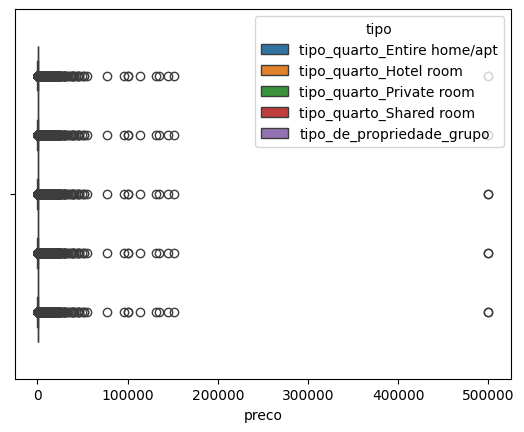

In [6]:
sns.boxplot(x=df["preco"], hue=df["tipo"])
plt.show()

plt.show()

#grafico para avaliar os outliers no dataframe sem tratamento dos outliers

In [ ]:
#outliers
df["preco"].sort_values(ascending=False).head(20)
#verificando valores

In [ ]:
print(df["preco"].quantile([0.90, 0.95, 0.99, 1.0]))
#mostra a distribuição dos preços, e justifica a decisão de cortar os valores acima de 7000

In [ ]:
df_tratado = df[df["preco"] <= 7000].copy()

#Limita o preco das diaria ate 13k

In [ ]:
sns.boxplot(x="hospedes", y="preco", hue="tipo", data=df_tratado)
plt.show()

In [ ]:
df.shape[0], df_tratado.shape[0]

#mostra os dois dataframes

In [ ]:
print(f"Antes: {df.shape[0]} linhas")
print(f"Depois: {df_tratado.shape[0]} linhas")
print(f"Removidos: {df.shape[0] - df_tratado.shape[0]} linhas")

In [ ]:
df_tratado["preco"].describe()

In [ ]:
df["preco"].sort_values(ascending=True).head(20)

#mostra valores em forma crescente

In [ ]:
contagem = df["banheiros"].value_counts().reset_index()
contagem.columns = ["banheiros", "contagem"]
contagem = contagem.sort_values("banheiros").reset_index(drop=True)

contagem["percentual"] = (contagem["contagem"] / contagem["contagem"].sum() * 100).round(2)
contagem["percentual_acumulado"] = contagem["percentual"].cumsum().round(2)

contagem

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["banheiros"])

plt.title("Distribuição da variável banheiros")
plt.xlabel("Banheiros")
plt.show()

In [ ]:
contagem = df["quartos"].value_counts().reset_index()
contagem.columns = ["quartos", "contagem"]
contagem = contagem.sort_values("quartos").reset_index(drop=True)

contagem["percentual"] = (contagem["contagem"] / contagem["contagem"].sum() * 100).round(2)
contagem["percentual_acumulado"] = contagem["percentual"].cumsum().round(2)

contagem

In [ ]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df["quartos"])

plt.title("Distribuição da variável quartos")
plt.xlabel("Quartos")
plt.show()

In [ ]:
df_tratado_price_min = df_tratado[
    (df_tratado["preco"] >= 65) &
    (df_tratado["quartos"] <= 15) &
    (df_tratado["banheiros"] <= 12)
].copy()

#atribui ao novo dataframe valores de limete pós remocao de outliers

In [ ]:
print(df_tratado_price_min["preco"].quantile([0.90, 0.95, 0.99, 1.0]))

In [ ]:
print(f"Antes: {df_tratado.shape[0]} linhas")
print(f"Depois: {df_tratado_price_min.shape[0]} linhas")
print(f"Removidos: {df_tratado.shape[0] - df_tratado_price_min.shape[0]} linhas")

In [ ]:
df_tratado_price_min["preco"].describe()

In [ ]:
df_tratado_price_min = df_tratado_price_min.melt(id_vars = ['preco', 'hospedes', 'quartos', 'camas', 'nota_avaliacao',
                 'noites_minimas', 'quantidade_avaliacoes', 'tipo_de_propriedade',
                 'latitude', 'longitude', 'bairro', 'ano', 'mes', 'banheiros',
                 'bairro_encode', 'ano_mes', 'ipca_mensal','ipca_acumulado_ano', 'lat_bin', 'lon_bin'], 
      var_name='tipo', value_name='valor').drop('valor',axis=1)

In [ ]:
sns.boxplot(x="hospedes", y="preco", hue="tipo", data=df_tratado_price_min)
plt.show()

In [ ]:
sns.boxplot(x="hospedes", y="preco", data=df_tratado_price_min, showfliers=False)
plt.show()

In [ ]:
print("Registros originais:", len(df_tratado))
print("Registros após remoção de outliers:", len(df_tratado_price_min))

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="quartos",
    y="preco"
)

plt.title("Distribuição do preço por número de quartos")
plt.xlim(-0.5, 11.5)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_tratado_price_min,
    x="quartos",
    y="preco",
    showfliers=False
)

plt.title("Distribuição do preço por número de quartos")
plt.xlim(-0.5, 11.5)
plt.show()

In [ ]:
df_box_banheiros = df_tratado_price_min[df_tratado_price_min["banheiros"] <=10].copy()

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_box_banheiros,
    x="banheiros",
    y="preco"
)

plt.title("Distribuição do preço por número de banheiros (até 10)")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária")

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_box_banheiros,
    x="banheiros",
    y="preco",
    showfliers=False
)

plt.title("Distribuição do preço por número de banheiros (até 10)")
plt.xlabel("Número de banheiros")
plt.ylabel("Preço da diária")

plt.show()

In [ ]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df_tratado_price_min,
    x="nota_avaliacao",
    y="preco",
    alpha=0.4
)

plt.title("Nota de avaliação vs Preço")
plt.xlabel("Nota de avaliação")
plt.ylabel("Preço da diária (R$)")
plt.show()


In [ ]:
mapa_tipos = {
    "tipo_quarto_Entire home/apt": "Casa/Apto Inteiro",
    "tipo_quarto_Hotel room": "Quarto de Hotel",
    "tipo_quarto_Private room": "Quarto Privado",
    "tipo_quarto_Shared room": "Quarto Compartilhado",
    "tipo_de_propriedade_grupo": "Outros"
}

df_boxplot = df_tratado_price_min.copy()

df_boxplot["Tipo de hospedagem"] = None

for coluna, nome in mapa_tipos.items():
    df_boxplot.loc[df_boxplot[coluna] == 1, "Tipo de hospedagem"] = nome


ordem = (
    df_boxplot
    .groupby("Tipo de hospedagem")["preco"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_boxplot,
    x="Tipo de hospedagem",
    y="preco",
    order=ordem,
    hue="Tipo de hospedagem",
    palette="viridis",
    legend=False
)

plt.title("Distribuição do preço por tipo de hospedagem")
plt.xlabel("Tipo de hospedagem")
plt.ylabel("Preço da diária")
plt.xticks(rotation=30)
plt.show()

In [ ]:
ordem = (
    df_boxplot
    .groupby("Tipo de hospedagem")["preco"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_boxplot,
    x="Tipo de hospedagem",
    y="preco",
    order=ordem,
    hue="Tipo de hospedagem",
    palette="viridis",
    legend=False,
    showfliers=False
)

plt.title("Distribuição do preço por tipo de hospedagem")
plt.xlabel("Tipo de hospedagem")
plt.ylabel("Preço da diária")
plt.xticks(rotation=30)
plt.show()

In [ ]:
df_tratado_price_min[
    [
        "preco",
        "hospedes",
        "quartos",
        "camas",
        "nota_avaliacao",
        "noites_minimas",
        "quantidade_avaliacoes",
        "latitude",
        "longitude",
        "banheiros",
        "tipo_quarto_Entire home/apt",
        "tipo_quarto_Hotel room",
        "tipo_quarto_Private room",
        "tipo_quarto_Shared room"
    ]
].describe()

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_tratado_price_min,
    x="longitude",
    y="latitude",
    hue="preco",
    palette="viridis",
    alpha=0.6
)

plt.title("Distribuição geográfica dos preços")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Preço", loc="best")
plt.show()

In [ ]:
df_tratado_price_min["lat_bin"] = df_tratado_price_min["latitude"].round(2)
df_tratado_price_min["lon_bin"] = df_tratado_price_min["longitude"].round(2)

In [ ]:
media_localizacao = (
    df_tratado_price_min
    .groupby(["lat_bin", "lon_bin"])["preco"]
    .mean()
    .reset_index()
)

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=media_localizacao,
    x="lon_bin",
    y="lat_bin",
    size="preco",
    hue="preco",
    palette="coolwarm",
    sizes=(20, 400),
    alpha=0.8
)

plt.title("Preço médio por localidade")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [ ]:
tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room"
}

In [ ]:
frequencias = []
total_registros = len(df_tratado_price_min)

for nome, coluna in tipos_imovel.items():
    freq_absoluta = df_tratado_price_min[coluna].sum()
    freq_relativa = freq_absoluta / total_registros

    frequencias.append({
        "Tipo de imóvel": nome,
        "Frequência relativa": freq_relativa
    })

df_frequencia = pd.DataFrame(frequencias)
df_frequencia["Frequência (%)"] = df_frequencia["Frequência relativa"] * 100

# =========================
# TABELA FINAL
# =========================

df_frequencia

In [ ]:
tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room",
    "Outros": "tipo_de_propriedade_grupo"
}

In [ ]:
media_precos = []

for nome, coluna in tipos_imovel.items():
    preco_medio = df_tratado_price_min.loc[
        df_tratado_price_min[coluna] == 1, "preco"
    ].mean()
    
    media_precos.append({
        "Tipo de imóvel": nome,
        "Preço médio": preco_medio
    })

df_media = pd.DataFrame(media_precos)




df_media

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media,
    x="Tipo de imóvel",
    y="Preço médio",
    palette="viridis"
)

df_media = df_media.sort_values(
    by="Preço médio",
    ascending=False
)

plt.title("Preço médio da diária por tipo de imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Preço médio da diária")
plt.xticks(rotation=30)
plt.show()

In [ ]:
tipos_imovel = {
    "Casa/apt Inteiro": "tipo_quarto_Entire home/apt",
    "Quarto de Hotel": "tipo_quarto_Hotel room",
    "Quarto Privado": "tipo_quarto_Private room",
    "Quarto Compartilhado": "tipo_quarto_Shared room",
    "Outros": "tipo_de_propriedade_grupo"
}



mediana_precos = []

for nome, coluna in tipos_imovel.items():
    preco_mediano = df_tratado_price_min.loc[
        df_tratado_price_min[coluna] == 1, "preco"
    ].median()
    
    mediana_precos.append({
        "Tipo de imóvel": nome,
        "Preço mediano": preco_mediano
    })

df_mediana = pd.DataFrame(mediana_precos)

df_mediana


df_mediana = df_mediana.sort_values(
    by="Preço mediano",
    ascending=False
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mediana,
    x="Tipo de imóvel",
    y="Preço mediano",
    palette="viridis"
)

plt.title("Preço mediano da diária por tipo de imóvel")
plt.xlabel("Tipo de imóvel")
plt.ylabel("Preço mediano da diária")
plt.xticks(rotation=30)
plt.show()

In [ ]:
df_tratado_price_min[df_tratado_price_min["bairro"] == "Copacabana"]["preco"].mean()

In [ ]:
top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)

In [ ]:
df_media_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .mean()
    .reset_index()
)

# manter apenas bairros mais procurados
df_media_acomodacao = df_media_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)

In [ ]:
df_media_acomodacao = df_media_acomodacao.sort_values("preco", ascending=False)

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_media_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Valor médio da diária nos bairros mais procurados por turistas")
plt.xlabel("Bairro")
plt.ylabel("Valor médio da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
top_bairros = (
    df_tratado_price_min
    .groupby("bairro")
    .size()
    .reset_index(name="total_anuncios")
    .sort_values("total_anuncios", ascending=False)
    .head(10)
)


df_mediana_acomodacao = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .median()
    .reset_index()
)


df_mediana_acomodacao = df_mediana_acomodacao.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


df_mediana_acomodacao = df_mediana_acomodacao.sort_values(
    "preco",
    ascending=False
)


plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mediana_acomodacao,
    x="bairro",
    y="preco",
    palette="viridis"
)

plt.title("Preço mediano da diária nos bairros com mais anúncios")
plt.xlabel("Bairro")
plt.ylabel("Preço mediano da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
df_mediana_bairros = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .median()
    .reset_index()
    .rename(columns={"preco": "mediana_preco"})
    .sort_values("mediana_preco", ascending=False)
    .reset_index(drop=True)
)

df_mediana_bairros

In [ ]:
df_contagem_bairros = (
    df_tratado_price_min
    .groupby("bairro")["preco"]
    .count()
    .reset_index()
    .rename(columns={"preco": "total_anuncios"})
    .sort_values("total_anuncios", ascending=True)
    .reset_index(drop=True)
)

df_contagem_bairros

In [ ]:
df_top_bairros = df_tratado_price_min.merge(
    top_bairros[["bairro"]],
    on="bairro",
    how="inner"
)


ordem_bairros = (
    df_top_bairros
    .groupby("bairro")["preco"]
    .median()
    .sort_values()
    .index
)


plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_bairros,
    x="bairro",
    y="preco",
    order=ordem_bairros,
    palette="viridis"
)

plt.title("Distribuição do preço da diária nos bairros mais procurados")
plt.xlabel("Bairro")
plt.ylabel("Preço da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_top_bairros,
    x="bairro",
    y="preco",
    order=ordem_bairros,
    palette="viridis",
    showfliers=False
)

plt.title("Distribuição do preço da diária nos bairros mais procurados")
plt.xlabel("Bairro")
plt.ylabel("Preço da diária (R$)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
variaveis = [
    "preco",
    "quartos",
    "banheiros",
    "latitude",
    "longitude",
    "camas",
    "nota_avaliacao",
    "quantidade_avaliacoes",
    "tipo_quarto_Entire home/apt",
    "tipo_quarto_Hotel room",
    "tipo_quarto_Private room",
    "tipo_quarto_Shared room"
]

df_corr = df_tratado_price_min[variaveis]

#df_corr = df_corr[df_corr["tipo_quarto_Hotel room"] == 1]

In [ ]:
df_corr.to_csv("df_corr.csv")

In [ ]:
corr_matrix = df_corr.corr()

In [ ]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis com o Preço da Diária")
plt.show()

In [ ]:
# variável alvo
y = df_corr["preco"]

# variáveis explicativas
X = df_corr.drop(columns=["preco", "tipo_quarto_Entire home/apt", "tipo_quarto_Hotel room", "tipo_quarto_Private room", "tipo_quarto_Shared room", "camas", "nota_avaliacao", "quantidade_avaliacoes"])
X.head()


In [ ]:
df_corr[df_corr["tipo_quarto_Entire home/apt"] == 1]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#train/test split, separa em dados para treino e para teste

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor

modelo = ExtraTreesRegressor(
)

modelo.fit(X_train, y_train)
#treina o modelo pela primeira vez

In [ ]:
y_pred = modelo.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_full = mean_absolute_error(y_test, y_pred)
rmse_full = np.sqrt(mean_squared_error(y_test, y_pred))
r2_full = r2_score(y_test, y_pred)

In [ ]:
print("MODELO COMPLETO SEM LOG")
print("MAE:", mae_full)
print("RMSE:", rmse_full)
print("R²:", r2_full)

In [ ]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)
#o modelo escolhe quais variaveis sao mais importantes

In [ ]:
importancias.head(10).plot(kind="barh")
plt.title("Top 10 Variáveis Mais Importantes")
plt.gca().invert_yaxis()
plt.show()
#grafico com as variaveis mais importantes

In [ ]:
top_features = importancias.head(10).index.tolist()

print("Variáveis selecionadas:", top_features)
#pega as top variaveis mais importantes

In [ ]:
X = X[top_features]
#redefine o X com essas variaveis

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#separa entre train/test novamente

In [ ]:
modelo.fit(X_train, y_train)
#treina o modelo novamente

In [ ]:
y_pred = modelo.predict(X_test)
#previsao

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MODELO REDUZIDO SEM LOG")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)
#avalia o desempenho do modelo

In [ ]:
#MODELO COM TRANSFORMAÇÃO LOG
y = np.log(df_corr["preco"])
X = df_corr.drop(columns=["preco"])



In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#train/test split, separa em dados para treino e para teste

In [ ]:
modelo = ExtraTreesRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

modelo.fit(X_train, y_train)
#treina o modelo pela primeira vez

In [ ]:
y_pred_log = modelo.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)

In [ ]:
mae_full = mean_absolute_error(y_test_real, y_pred)
rmse_full = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2_full = r2_score(y_test_real, y_pred)



In [ ]:
print("MODELO COMPLETO COM LOG")
print("MAE:", mae_full)
print("RMSE:", rmse_full)
print("R²:", r2_full)

In [ ]:
importancias = pd.Series(
    modelo.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importancias)
#o modelo escolhe quais variaveis sao mais importantes

In [ ]:
top_features = importancias.head(10).index.tolist()
X = X[top_features]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#separa entre train/test novamente

In [ ]:
modelo.fit(X_train, y_train)

In [ ]:
y_pred_log = modelo.predict(X_test)
y_pred = np.exp(y_pred_log)
y_test_real = np.exp(y_test)


In [ ]:
mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

In [ ]:
print("MODELO REDUZIDO COM LOG")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)